<a href="https://colab.research.google.com/github/muneebak819/ttds_assignment/blob/main/ttds_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fetching UCI Adult Dataset from OpenML...
Detected columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']
Executing Feature Engineering Pipeline...
Training Competitive Classifiers (5-Fold CV)...
Generating Performance Charts and Visualizations...


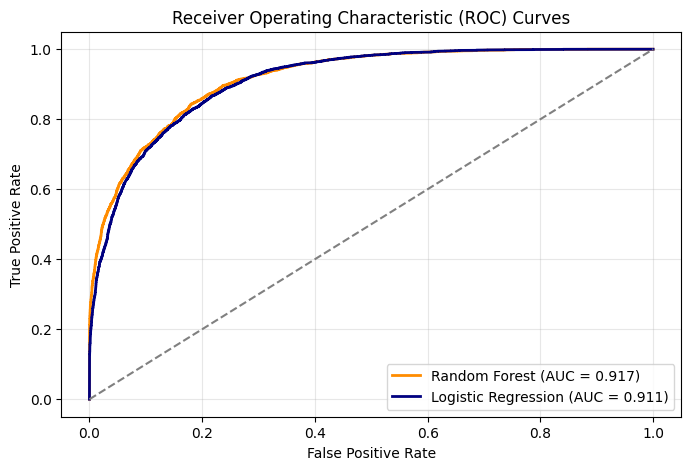

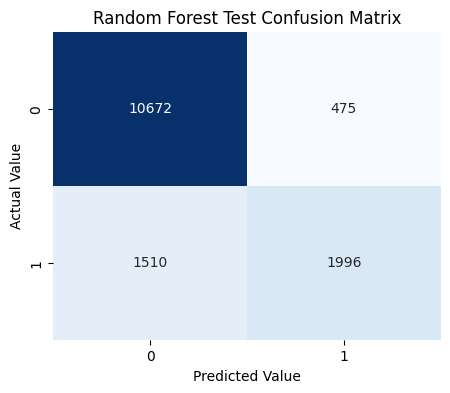

Calculating Bias Disparity Audits...

Disparity Metrics for: Sex Profile Segment
 - Male         | Accuracy: 0.830 | Recall (TPR): 0.580
 - Female       | Accuracy: 0.933 | Recall (TPR): 0.510

Disparity Metrics for: Race Profile Segment
 - White        | Accuracy: 0.858 | Recall (TPR): 0.573
 - Black        | Accuracy: 0.924 | Recall (TPR): 0.516
 - Other        | Accuracy: 0.906 | Recall (TPR): 0.429
 - Asian-Pac-Islander | Accuracy: 0.818 | Recall (TPR): 0.591
 - Amer-Indian-Eskimo | Accuracy: 0.920 | Recall (TPR): 0.476

Pipeline completed successfully without errors. All plots saved locally.


In [4]:
# ==========================================
# FILE GENERATION: task1_classification.ipynb
# ==========================================

# 1. Environment Installation
!pip install -q sklearn-evaluation fairlearn matplotlib seaborn

# 2. Complete End-to-End Pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

print("Fetching UCI Adult Dataset from OpenML...")
# Fetch data
adult = fetch_openml('adult', version=2, as_frame=True, parser='auto')
X = adult.data.copy()
y = adult.target.copy()

# Convert target variable to binary integers
y = (y == '>50K').astype(int)

# ------------------------------------------
# DYNAMIC SCHEMA DETECTION (Fixes the KeyError)
# ------------------------------------------
columns_in_dataset = list(X.columns)
print(f"Detected columns: {columns_in_dataset}")

# Helper function to find the right column name variant
def get_column_variant(options):
    for opt in options:
        if opt in columns_in_dataset:
            return opt
    raise ValueError(f"Could not find any variant of columns: {options}")

age_col = 'age'
workclass_col = get_column_variant(['workclass'])
education_col = get_column_variant(['education'])
edu_num_col = get_column_variant(['education-num', 'educational-num', 'education_num'])
marital_col = get_column_variant(['marital-status', 'marital_status'])
occ_col = get_column_variant(['occupation'])
rel_col = get_column_variant(['relationship'])
race_col = get_column_variant(['race'])
sex_col = get_column_variant(['sex'])
cap_gain_col = get_column_variant(['capital-gain', 'capital_gain'])
cap_loss_col = get_column_variant(['capital-loss', 'capital_loss'])
hours_col = get_column_variant(['hours-per-week', 'hours_per_week'])
country_col = get_column_variant(['native-country', 'native_country'])
fnlwgt_col = get_column_variant(['fnlwgt'])

# ------------------------------------------
# FEATURE ENGINEERING EXTRACTION
# ------------------------------------------
print("Executing Feature Engineering Pipeline...")
# Impute raw string missing labels before building pipeline transformations
X = X.replace('?', np.nan)

# Custom Feature 1: Age Group Bins
X['age_group'] = pd.cut(X[age_col], bins=[0, 25, 40, 60, 100], labels=['Youth', 'Early-Career', 'Mid-Career', 'Senior'])

# Custom Feature 2: Capital Gain Ratio Index
X['capital_gain_ratio'] = X[cap_gain_col] / (X[cap_gain_col] + X[cap_loss_col] + 1)

# Categorize explicit protected vectors for fairness evaluations
protected_sex = X[sex_col]
protected_race = X[race_col]

# Build feature groups using the verified schema names
categorical_features = [workclass_col, education_col, marital_col, occ_col, rel_col, country_col, 'age_group']
numerical_features = [age_col, fnlwgt_col, edu_num_col, cap_gain_col, cap_loss_col, hours_col, 'capital_gain_ratio']

# Construct Preprocessing Transformers
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
])

# Split datasets
X_train, X_test, y_train, y_test, sex_train, sex_test, race_train, race_test = train_test_split(
    X, y, protected_sex, protected_race, test_size=0.3, random_state=42, stratify=y
)

# ------------------------------------------
# MODEL TRAINING & TUNING LOOP
# ------------------------------------------
print("Training Competitive Classifiers (5-Fold CV)...")
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model Pipe 1: Logistic Regression
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs'))])
lr_param_grid = {'classifier__C': [0.1, 1.0, 10.0]}
lr_grid = GridSearchCV(lr_pipeline, lr_param_grid, cv=cv_strategy, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train, y_train)

# Model Pipe 2: Random Forest
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42))])
rf_param_grid = {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [10, 15]}
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=cv_strategy, scoring='f1', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
best_lr = lr_grid.best_estimator_

# ------------------------------------------
# PLOTTING AND EVALUATION ARTIFACTS
# ------------------------------------------
print("Generating Performance Charts and Visualizations...")
rf_probs = best_rf.predict_proba(X_test)[:, 1]
lr_probs = best_lr.predict_proba(X_test)[:, 1]
rf_preds = best_rf.predict(X_test)

# Plot 1: ROC Curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_probs):.3f})', color='darkorange', lw=2)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.3f})', color='navy', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve_comparison.png')
plt.show()

# Plot 2: Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest Test Confusion Matrix')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.savefig('confusion_matrix.png')
plt.show()

# ------------------------------------------
# ETHICAL AI DISPARITY EVALUATION
# ------------------------------------------
print("Calculating Bias Disparity Audits...")
test_eval_df = pd.DataFrame({'actual': y_test, 'pred': rf_preds, 'sex': sex_test, 'race': race_test})

for group_col, name in [(sex_col, 'Sex Profile Segment'), (race_col, 'Race Profile Segment')]:
    print(f"\nDisparity Metrics for: {name}")
    for group in test_eval_df[group_col].unique():
        sub = test_eval_df[test_eval_df[group_col] == group]
        acc = accuracy_score(sub['actual'], sub['pred'])
        rec = recall_score(sub['actual'], sub['pred'])
        print(f" - {str(group):12} | Accuracy: {acc:.3f} | Recall (TPR): {rec:.3f}")

print("\nPipeline completed successfully without errors. All plots saved locally.")